In [1]:
# Import necessary libraries for data manipulation and visualization
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Set Seaborn style for better aesthetics
sns.set(style="whitegrid")

In [2]:
# Load the Palmer Penguins dataset
df = pd.read_csv("/Users/sam/Documents/DI_DATA_2025/Palmer Penguins Dataset.csv")  # Replace with the correct path if needed

# Display the first few rows
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [3]:
# Display basic info about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
 7   year               344 non-null    int64  
dtypes: float64(4), int64(1), object(3)
memory usage: 21.6+ KB


In [4]:
# Check for missing values
df.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64

In [5]:
# Drop rows with missing values
df.dropna(inplace=True)

# Check again
df.isnull().sum()


species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
year                 0
dtype: int64

In [6]:
# Get basic statistics
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,333.000000,333.000000,333.000000,333.000000,333.000000
mean,43.992793,17.164865,200.966967,4207.057057,2008.042042
std,5.468668,1.969235,14.015765,805.215802,0.812944
min,32.100000,13.100000,172.000000,2700.000000,2007.000000
25%,39.500000,15.600000,190.000000,3550.000000,2007.000000
50%,44.500000,17.300000,197.000000,4050.000000,2008.000000
75%,48.600000,18.700000,213.000000,4775.000000,2009.000000
max,59.600000,21.500000,231.000000,6300.000000,2009.000000


In [7]:
# Show unique values for categorical columns
df[['species', 'island', 'sex', 'year']].nunique()

species    3
island     3
sex        2
year       3
dtype: int64

#Species distribution (Bar Chart)

/var/folders/98/72mf16fn6sv4h6j6pj3w1__h0000gn/T/ipykernel_41930/1859477050.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='species', data=df, palette='Set2')


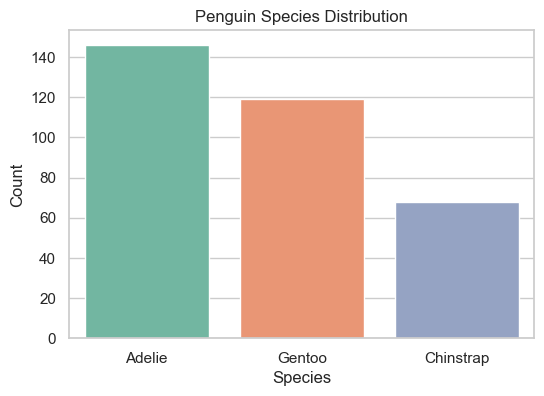

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x='species', data=df, palette='Set2')
plt.title('Penguin Species Distribution')
plt.xlabel('Species')
plt.ylabel('Count')
plt.show()

Flipper Length vs. Body Mass (Scatter Plot)

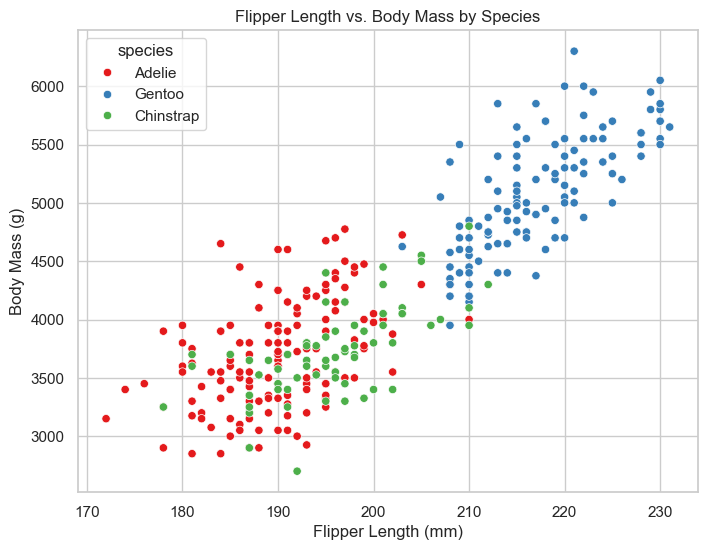

In [9]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='flipper_length_mm', y='body_mass_g', hue='species', palette='Set1')
plt.title('Flipper Length vs. Body Mass by Species')
plt.xlabel('Flipper Length (mm)')
plt.ylabel('Body Mass (g)')
plt.show()

Island Distribution (Pie Chart)

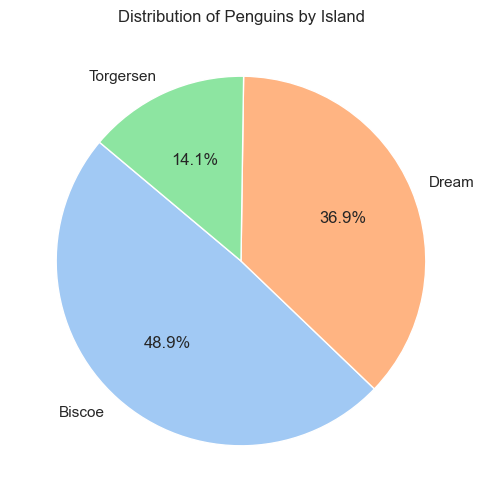

In [10]:
# Calculate counts per island
island_counts = df['island'].value_counts()

# Plot as pie chart
plt.figure(figsize=(6,6))
island_counts.plot.pie(autopct='%1.1f%%', startangle=140, colors=sns.color_palette("pastel"))
plt.title('Distribution of Penguins by Island')
plt.ylabel('')
plt.show()

Sex Distribution within Species (Grouped Bar Chart)

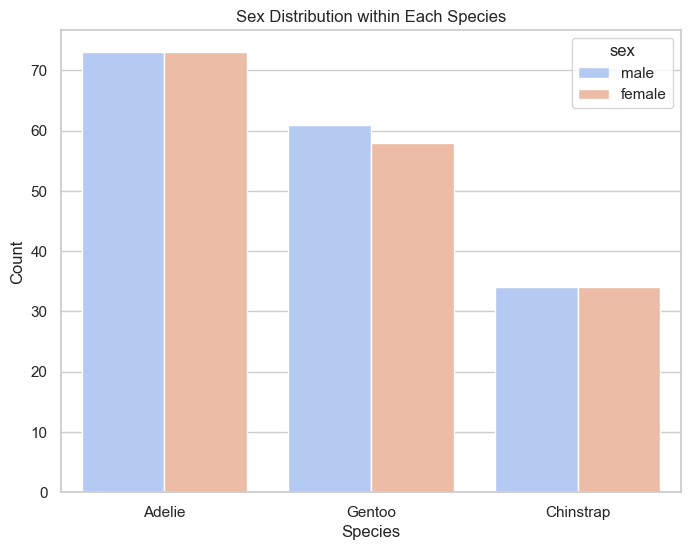

In [11]:
plt.figure(figsize=(8,6))
sns.countplot(x='species', hue='sex', data=df, palette='coolwarm')
plt.title('Sex Distribution within Each Species')
plt.xlabel('Species')
plt.ylabel('Count')
plt.show()


Heatmap of Correlations

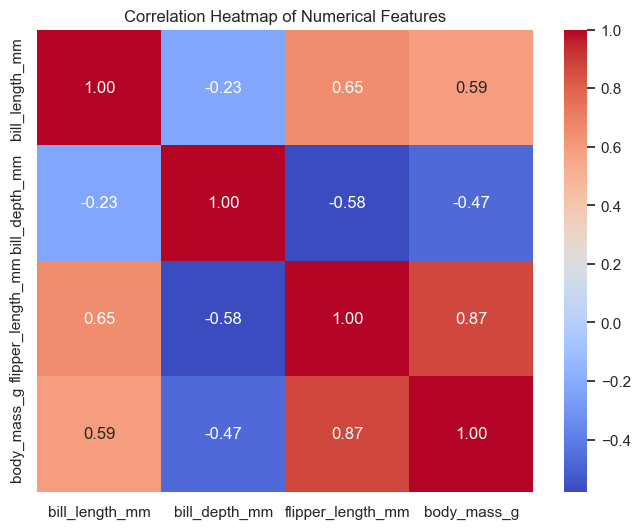

In [12]:
# Compute correlation matrix
corr = df[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']].corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

Boxplots for Measurements by Species

/var/folders/98/72mf16fn6sv4h6j6pj3w1__h0000gn/T/ipykernel_41930/1413398610.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species', y='flipper_length_mm', data=df, palette='Set3')


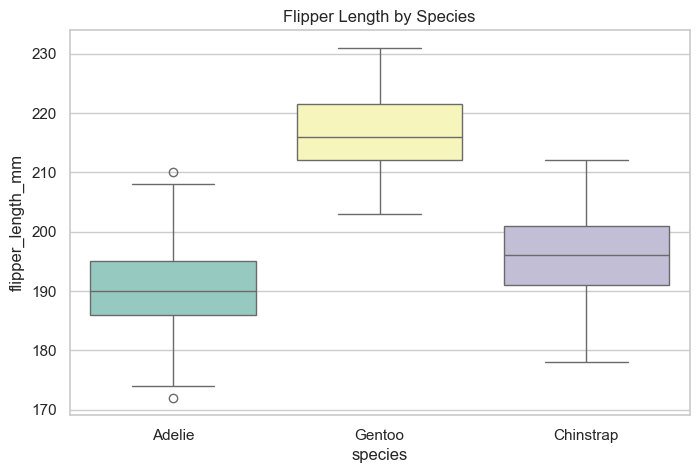

In [13]:
# Flipper length boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x='species', y='flipper_length_mm', data=df, palette='Set3')
plt.title('Flipper Length by Species')
plt.show()

/var/folders/98/72mf16fn6sv4h6j6pj3w1__h0000gn/T/ipykernel_41930/2035431671.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species', y='body_mass_g', data=df, palette='Set2')


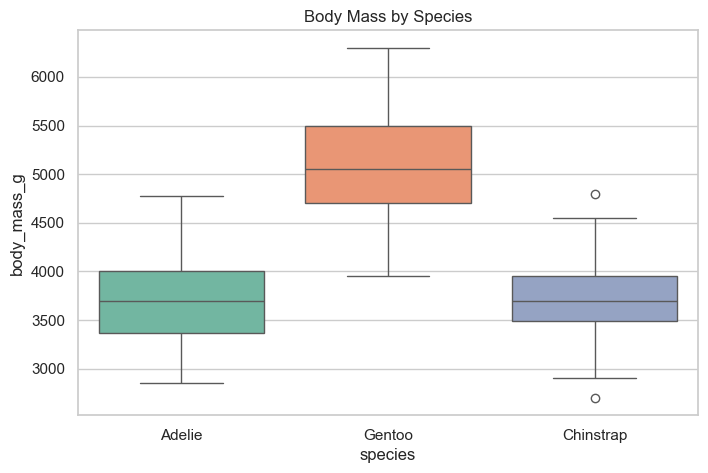

In [14]:
# Body mass boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x='species', y='body_mass_g', data=df, palette='Set2')
plt.title('Body Mass by Species')
plt.show()

/var/folders/98/72mf16fn6sv4h6j6pj3w1__h0000gn/T/ipykernel_41930/687996243.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species', y='bill_length_mm', data=df, ax=ax[0], palette='Set1')
/var/folders/98/72mf16fn6sv4h6j6pj3w1__h0000gn/T/ipykernel_41930/687996243.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species', y='bill_depth_mm', data=df, ax=ax[1], palette='Set1')


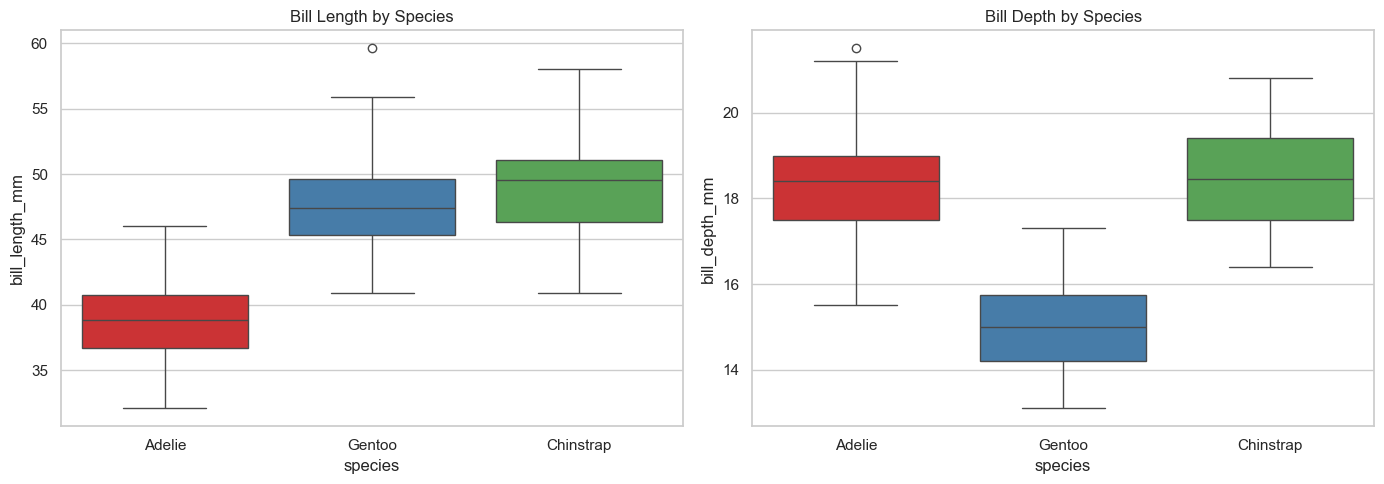

In [15]:
# Bill length and depth
fig, ax = plt.subplots(1, 2, figsize=(14,5))
sns.boxplot(x='species', y='bill_length_mm', data=df, ax=ax[0], palette='Set1')
ax[0].set_title('Bill Length by Species')
sns.boxplot(x='species', y='bill_depth_mm', data=df, ax=ax[1], palette='Set1')
ax[1].set_title('Bill Depth by Species')
plt.tight_layout()
plt.show()


Histograms of Key Measurements

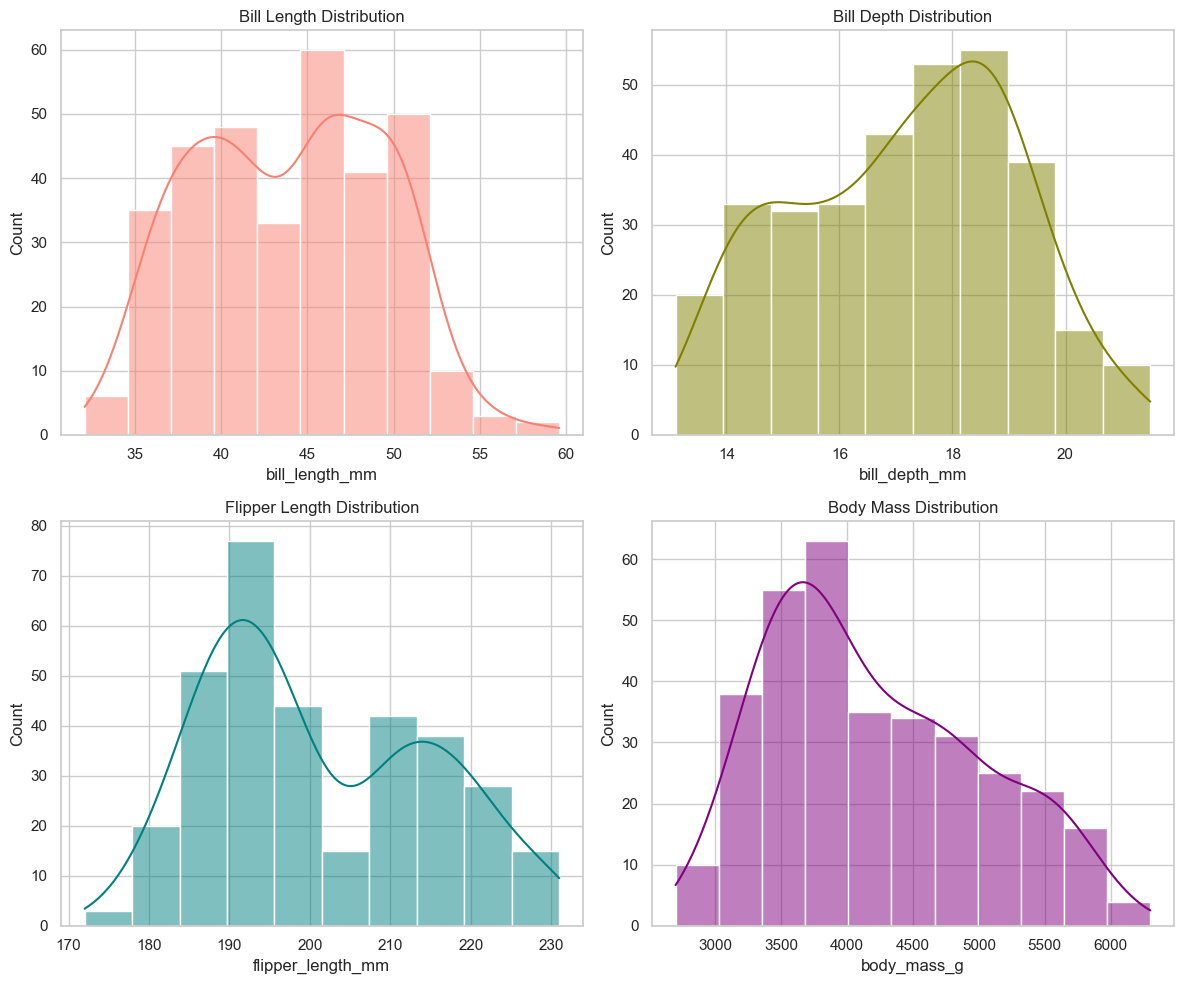

In [16]:
# Create subplots to compare features
fig, axs = plt.subplots(2, 2, figsize=(12,10))

sns.histplot(df['bill_length_mm'], kde=True, ax=axs[0, 0], color='salmon')
axs[0, 0].set_title('Bill Length Distribution')

sns.histplot(df['bill_depth_mm'], kde=True, ax=axs[0, 1], color='olive')
axs[0, 1].set_title('Bill Depth Distribution')

sns.histplot(df['flipper_length_mm'], kde=True, ax=axs[1, 0], color='teal')
axs[1, 0].set_title('Flipper Length Distribution')

sns.histplot(df['body_mass_g'], kde=True, ax=axs[1, 1], color='purple')
axs[1, 1].set_title('Body Mass Distribution')

plt.tight_layout()
plt.show()

Seaborn Pairplot

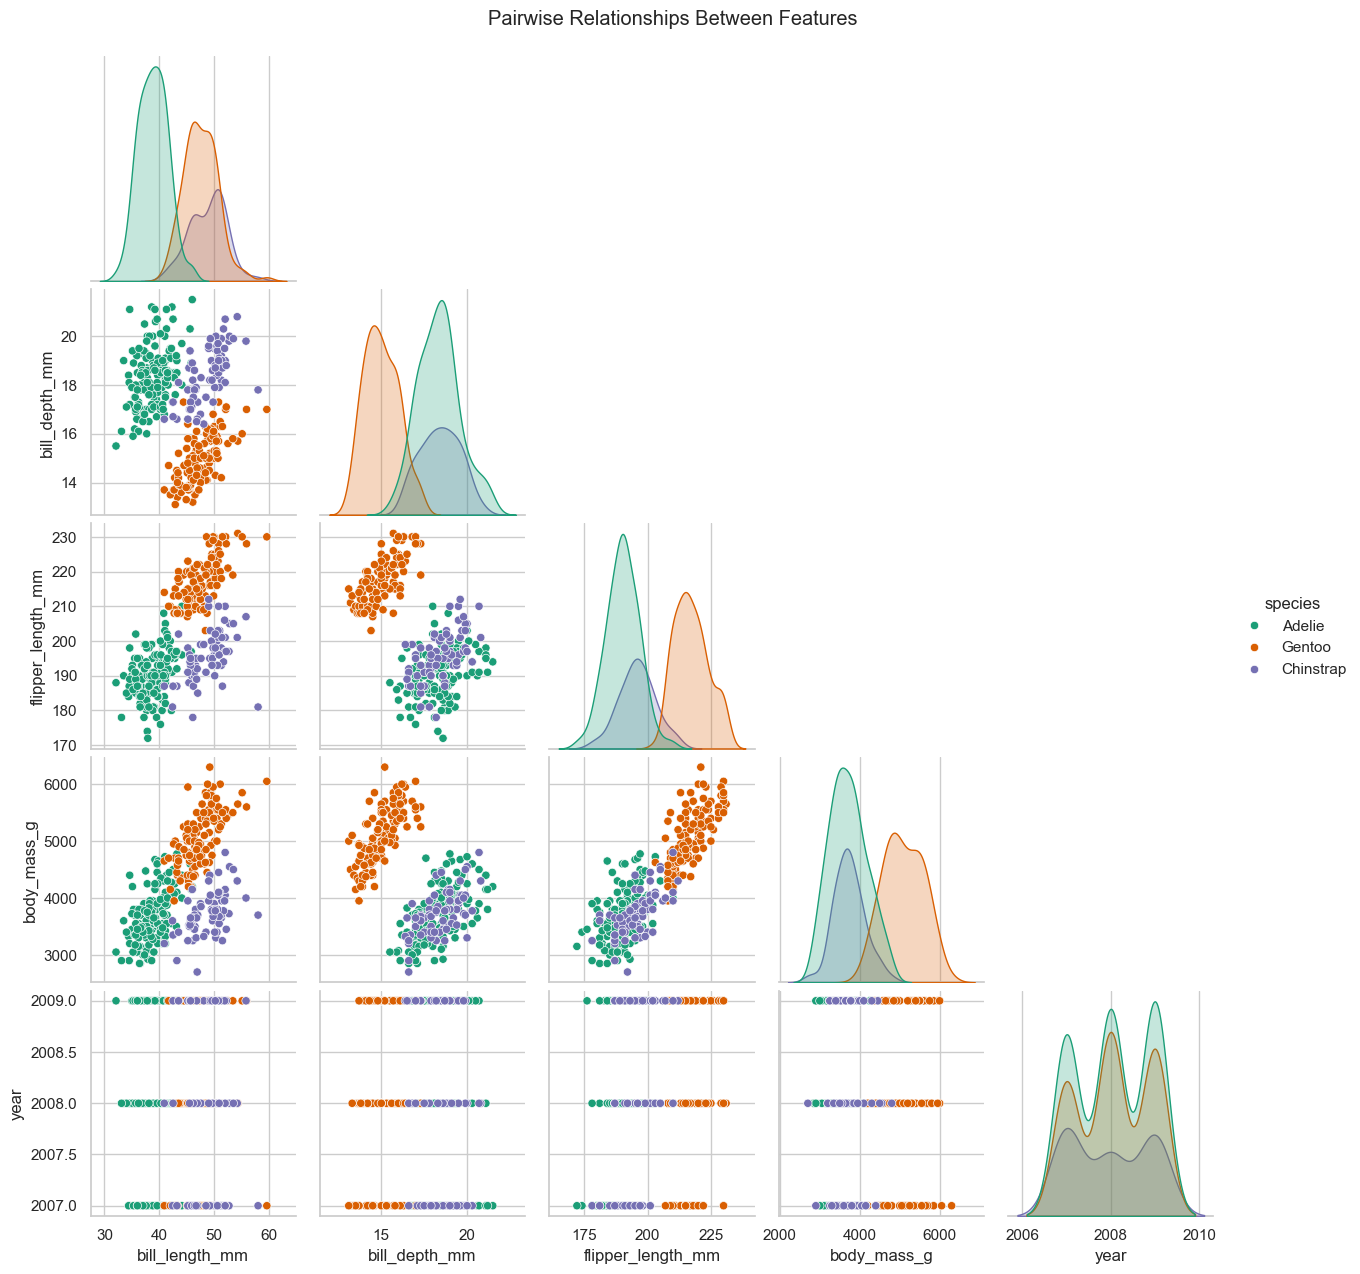

In [17]:
# Create a pairplot colored by species
sns.pairplot(df, hue='species', corner=True, palette='Dark2')
plt.suptitle('Pairwise Relationships Between Features', y=1.02)
plt.show()

Key Insights:
- Adelie is the most frequent species in the dataset.
- Gentoo penguins tend to be heavier and have longer flippers.
- Flipper length and body mass are positively correlated.
- Islands and sex distribution vary across species.
- Several measurements are useful to distinguish between species.

Visualization helps uncover patterns that are not obvious in raw data.